# Drunkard's Walk

**Domain:** Procedural Generation  ·  **recommended addition**  ·  **runnable:** yes

A refresher on the drunkard's walk (a.k.a. random-walk carving): the simplest
algorithm for generating organic, cave-like maps. A single "drunk" agent
staggers around a solid grid, digging out floor wherever it stumbles.

## 1. What & Why

The **drunkard's walk** carves a level by simulating a random walk. Start with a
grid that is entirely *wall*. Drop a "digger" somewhere, then repeat: pick a
random cardinal direction, step one tile, set that tile to *floor*. Keep going
until enough of the map is carved (say 40% floor). The wandering path naturally
produces twisty, organic corridors and connected caverns — no hand-authoring,
no geometry math.

**The problem it solves.** You want a cave/dungeon that feels hand-dug and
*guaranteed connected*, with almost no code. Because every floor tile is reached
by extending an existing floor tile, the carved region is one contiguous blob —
the player can always walk from any floor tile to any other. That connectivity
guarantee is the headline feature; cellular-automata caves don't give it for
free (they need a post-pass to join islands).

**When to reach for it.**
- Roguelike caves, mines, organic tunnels, "natural" passages.
- Prototypes and game jams where you need *a* map in 20 lines.
- Anywhere you want connectivity for free and don't care about precise control
  over room shapes.

**When NOT to.** If you need rectangular rooms, symmetry, guaranteed corridor
widths, or designer control over layout, reach for BSP or hand-placed rooms.
The drunkard's walk is gloriously uncontrollable: that's its charm and its
curse. See [`bsp-dungeon-generation`](bsp-dungeon-generation.ipynb) and
[`cellular-automata`](cellular-automata.ipynb) for the structured/organic
alternatives.

## 2. Mental Model

Picture an **Etch A Sketch held by someone who's had a few too many.** They keep
twisting the knobs in random directions; the line they trace is the floor of
your cave. The longer they wander, the more of the screen fills in — and because
the line never lifts, everything it draws is one connected scribble.

```
Step 0            Step ~40            Step ~120
##########        ##########          ##########
##########        ####.#####          ##..####..
##########        ###...####          .#....#...
#####@####        ##..@.####     →    ##...@....
##########        ####.#####          ###..##..#
##########        ##########          #..####.##
##########        ##########          #####..###

  walker (@) staggers around; '.' is everything it has dug out
```

The walk is a **first-order Markov process** with no memory of where it's been —
each step depends only on the current position. That memorylessness is exactly
why the path crosses itself, doubles back, and clumps into rooms: revisiting
tiles is free and frequent.

## 3. Key Concepts

- **Digger / walker** — the agent carving floor. One walker gives a single
  connected blob; spawning several (or restarting at random carved tiles) makes
  bigger, branchier systems while staying connected.
- **Floor ratio (fill fraction)** — the stopping condition. Carve until
  `carved / total` hits a target (commonly 0.35–0.50). Higher ratio → more open
  cavern; lower → sparse twisty tunnels.
- **Step / move set** — the directions allowed per step. 4-way (von Neumann)
  gives blocky corridors; adding diagonals (8-way) loosens them. You can also
  bias the distribution to stretch the cave along an axis.
- **Bias / momentum** — make the walker prefer its previous direction (lower the
  chance of turning). More momentum → longer straight runs and less clumping;
  pure-random (no momentum) → dense, blobby caves.
- **Bounds handling** — keep the walker inside the grid. Clamp at the edge, or
  bounce, or wrap (torus). Clamping is the usual choice and keeps a solid wall
  border. Never carve the outermost ring if you want a sealed map.
- **Connectivity guarantee** — every newly carved tile is adjacent to the
  walker's path, so the carved set is always one connected component. This is the
  property that distinguishes it from cellular-automata caves.
- **Seed** — the RNG seed. Same seed + same parameters → identical map, which is
  what makes runs reproducible and debuggable.

## 4. Setup

Pure Python plus NumPy for the grid (a plain list-of-lists works too).
Matplotlib is optional — used only for a heatmap at the end and gated behind an
import check so the notebook runs without it.

```bash
%pip install numpy matplotlib
```

In [1]:
import numpy as np

# Optional plotting — the notebook runs fine without matplotlib.
try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False

WALL, FLOOR = 0, 1
print("numpy", np.__version__, "| matplotlib available:", HAVE_MPL)

numpy 2.4.6 | matplotlib available: True


## 5. Worked Examples

### Example 1 — A single drunken digger carves a cave

The whole algorithm in one function. We start solid, drop a walker in the
middle, and step in random cardinal directions until a target fraction of the
interior is floor. We clamp at the border so the outer ring stays wall.

In [2]:
def drunkards_walk(width, height, fill=0.40, seed=0):
    """Carve a cave with one random walker. Returns a (height, width) int grid."""
    rng = np.random.default_rng(seed)
    grid = np.zeros((height, width), dtype=int)  # all WALL

    # Interior tiles only (keep a 1-tile wall border).
    target = int(fill * (width - 2) * (height - 2))
    x, y = width // 2, height // 2
    grid[y, x] = FLOOR
    carved = 1

    # (dx, dy) for up/down/left/right
    moves = np.array([(0, -1), (0, 1), (-1, 0), (1, 0)])
    while carved < target:
        dx, dy = moves[rng.integers(4)]
        # Clamp inside the border [1, size-2].
        x = min(max(x + dx, 1), width - 2)
        y = min(max(y + dy, 1), height - 2)
        if grid[y, x] == WALL:
            grid[y, x] = FLOOR
            carved += 1
    return grid


def show(grid):
    glyphs = {WALL: "#", FLOOR: "."}
    print("\n".join("".join(glyphs[c] for c in row) for row in grid))


cave = drunkards_walk(40, 18, fill=0.40, seed=7)
show(cave)
print(f"\nfloor fraction: {cave.mean():.2f}")

########################################
#########################............#.#
#########################..............#
#########################........##....#
##########################.............#
########################.###...........#
#######################................#
################...##.#................#
################......#...........##...#
################...............#####..##
###############.......#.....#######..###
##############...............######.####
##############.....#.####.......##..#..#
#############.....#######...#......##..#
#############....#####......#......##..#
#############.#########.....#...#......#
########################.#.##..##......#
########################################

floor fraction: 0.34


### Example 2 — Connectivity is free, and parameters shape the cave

Two things to verify. First, the carved region is **a single connected
component** — the algorithm's main promise. We confirm it with a flood fill from
any floor tile: the flood should reach *every* floor tile. Second, we sweep the
fill fraction to see how it trades sparse tunnels for open caverns.

In [3]:
from collections import deque

def count_components(grid):
    """Number of connected floor regions (4-connectivity). Should be 1."""
    h, w = grid.shape
    seen = np.zeros_like(grid, dtype=bool)
    comps = 0
    for sy in range(h):
        for sx in range(w):
            if grid[sy, sx] == FLOOR and not seen[sy, sx]:
                comps += 1
                q = deque([(sy, sx)])
                seen[sy, sx] = True
                while q:
                    cy, cx = q.popleft()
                    for dy, dx in ((0, 1), (0, -1), (1, 0), (-1, 0)):
                        ny, nx = cy + dy, cx + dx
                        if (0 <= ny < h and 0 <= nx < w
                                and grid[ny, nx] == FLOOR and not seen[ny, nx]):
                            seen[ny, nx] = True
                            q.append((ny, nx))
    return comps


for fill in (0.25, 0.40, 0.60):
    g = drunkards_walk(60, 30, fill=fill, seed=3)
    print(f"fill={fill:.2f}  floor={g.mean():.2f}  "
          f"connected_components={count_components(g)}")

fill=0.25  floor=0.23  connected_components=1
fill=0.40  floor=0.36  connected_components=1
fill=0.60  floor=0.54  connected_components=1


The component count is always **1**, regardless of fill — the connectivity
guarantee holds. The next cell adds *momentum*: with probability `p_straight`
the walker keeps its previous heading instead of choosing freshly at random.
More momentum stretches the cave into longer tunnels; less makes it blobby. If
matplotlib is present we render a visit-frequency heatmap so you can *see* where
the walker lingered.

floor fraction: 0.41  components: 1
most-visited tile hit 85 times (walker doubles back a lot)


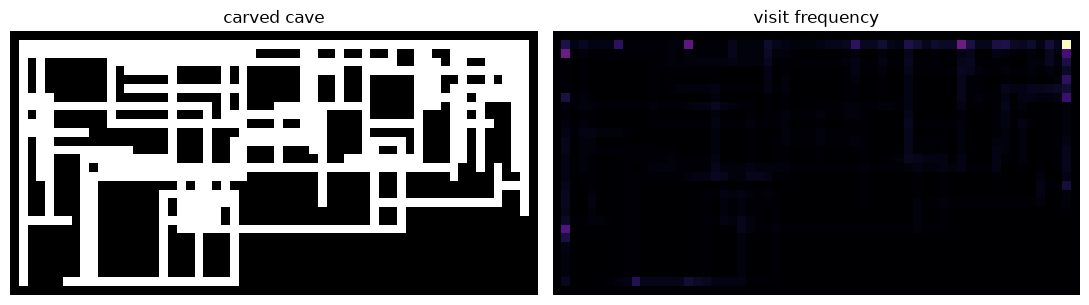

In [4]:
def drunkards_walk_momentum(width, height, fill=0.40, p_straight=0.7, seed=0):
    rng = np.random.default_rng(seed)
    grid = np.zeros((height, width), dtype=int)
    visits = np.zeros((height, width), dtype=int)
    moves = [(0, -1), (0, 1), (-1, 0), (1, 0)]
    target = int(fill * (width - 2) * (height - 2))

    x, y = width // 2, height // 2
    grid[y, x] = FLOOR
    d = moves[rng.integers(4)]
    carved = 1
    while carved < target:
        if rng.random() > p_straight:          # turn: pick a fresh direction
            d = moves[rng.integers(4)]
        x = min(max(x + d[0], 1), width - 2)
        y = min(max(y + d[1], 1), height - 2)
        visits[y, x] += 1
        if grid[y, x] == WALL:
            grid[y, x] = FLOOR
            carved += 1
    return grid, visits


cave, visits = drunkards_walk_momentum(60, 30, fill=0.45, p_straight=0.8, seed=11)
print(f"floor fraction: {cave.mean():.2f}  components: {count_components(cave)}")
print(f"most-visited tile hit {visits.max()} times "
      f"(walker doubles back a lot)")

if HAVE_MPL:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3))
    a1.imshow(cave, cmap="binary_r"); a1.set_title("carved cave"); a1.axis("off")
    a2.imshow(visits, cmap="magma");  a2.set_title("visit frequency"); a2.axis("off")
    plt.tight_layout(); plt.show()
else:
    show(cave)

## 6. Gotchas & Pitfalls

- **No stopping condition = infinite/expensive loop.** Always cap on a target
  floor count (or a max-steps budget). Counting steps instead of *carved* tiles
  is a classic bug: a walker doubling back over old floor never increases floor
  fraction, so a step-count cap can stop with far less carved than intended.
- **Walker escapes the grid.** Forgetting bounds handling throws an index error
  or carves the border. Clamp/bounce *before* writing the tile, and keep a 1-tile
  wall margin so the map stays sealed.
- **Carving the border ring** breaks "the outside is solid wall" invariants that
  rendering and collision often assume. Restrict the interior to `[1, size-2]`.
- **High fill = blobby mush.** Push fill past ~0.6 and the cave loses its
  tunnel character and becomes an open room. If you want big *and* twisty, use
  more walkers / longer maps rather than cranking a single walker's fill.
- **Slow convergence at high fill.** As the cave fills, random steps land on
  existing floor more and more often, so the last few percent of carving takes
  disproportionately many steps. Budget for it or stop earlier.
- **Pure randomness clumps.** With no momentum the walk lingers near its start
  (random walks have low expected displacement, ~√steps). Without bias you get a
  dense central blob, not sprawling tunnels. Add momentum or multiple seeds.
- **Reproducibility.** Seed the RNG (`np.random.default_rng(seed)`), not the
  global `random` state, so maps are deterministic and bugs are repeatable.

## 7. When to Use vs Alternatives

| Approach | Output character | Connectivity | Control | Use when |
|---|---|---|---|---|
| **Drunkard's walk** | organic, twisty tunnels/caves | **free** (one walk = one blob) | very low | you want a connected cave in ~20 lines |
| **Cellular automata** | blobby natural caverns | not guaranteed (needs join pass) | low | you want bigger, more cavernous caves |
| **BSP** | rectangular rooms + corridors | by construction | high | structured dungeons, designer control |
| **Voronoi / Delaunay** | irregular cells/regions | via region graph | medium | biome/region partitioning |
| **Perlin/Simplex threshold** | smooth blobby masks | not guaranteed | medium (via threshold) | terrain, islands, large-scale shape |

**Honest trade-offs.** The drunkard's walk wins on *simplicity* and *guaranteed
connectivity* and loses on *control*. You cannot easily ask it for "three rooms
joined by two corridors." Common upgrades that keep the spirit while adding
control: spawn multiple walkers from random carved tiles (bigger systems),
restart the walker periodically (branchier), add momentum (tunnels vs. blobs),
or run a drunkard's walk *first* for connectivity and a cellular-automata smooth
pass *after* for natural-looking walls. See
[`cellular-automata`](cellular-automata.ipynb),
[`bsp-dungeon-generation`](bsp-dungeon-generation.ipynb), and
[`markov-chains`](markov-chains.ipynb) (the walk is a first-order Markov
process).

## 8. Resources

- **RogueBasin — The Drunkard's Walk algorithm**: classic roguelike-dev writeup
  with variants. <https://roguebasin.com/index.php/Random_Walk_Cave_Generation>
- **Red Blob Games — map generation overview** (context on where random-walk
  fits among PCG techniques): <https://www.redblobgames.com/maps/terrain-from-noise/>
- **Herbert Wolverson, *Hands-on Rust* / the Rust Roguelike Tutorial** — a
  well-explained drunkard's-walk map builder chapter:
  <https://bfnightly.bracketproductions.com/rustbook/chapter_27.html>
- **Wikipedia — Random walk** (the math behind why it clumps; expected distance
  grows like √n): <https://en.wikipedia.org/wiki/Random_walk>
- Cross-links: [`cellular-automata`](cellular-automata.ipynb) ·
  [`bsp-dungeon-generation`](bsp-dungeon-generation.ipynb) ·
  [`markov-chains`](markov-chains.ipynb)